<a href="https://colab.research.google.com/github/giteshaggarwal123/FWWBIndia/blob/main/ZG536_FDS_Assignment1_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 ZG536 — Foundations of Data Science
## Assignment 1: Exploratory Data Analysis — Spotify Top Songs

**Student ID:** ZG536  
**Dataset:** Spotify Top Songs (2010–2019) — Kaggle  
**Dataset Source:** [https://www.kaggle.com/datasets/leonardopena/top-spotify-songs-from-20102019-by-year](https://www.kaggle.com/datasets/leonardopena/top-spotify-songs-from-20102019-by-year)

---

### 🎯 Objective
What makes a song go **viral**? This notebook explores Spotify's audio features —  
BPM, energy, danceability, loudness, valence, and more — to uncover what separates  
a hit song from the rest.

### 📦 Features in the Dataset
| Feature | Description |
|---|---|
| `title` | Song name |
| `artist` | Artist name |
| `top genre` | Music genre |
| `year` | Year the song charted |
| `bpm` | Beats per minute (tempo) |
| `nrgy` | Energy level (0–100) |
| `dnce` | Danceability (0–100) |
| `dB` | Loudness (decibels) |
| `live` | Liveness (0–100) |
| `val` | Valence / happiness (0–100) |
| `dur` | Duration (seconds) |
| `acous` | Acousticness (0–100) |
| `spch` | Speechiness (0–100) |
| `pop` | Popularity score (0–100) |

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a2e',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlecolor': 'white',
    'text.color': 'white',
    'grid.color': '#333355'
})

SPOTIFY_GREEN = '#1DB954'
SPOTIFY_PURPLE = '#9b59b6'
SPOTIFY_ORANGE = '#e07b54'
SPOTIFY_BLUE = '#5b8db8'

print('✅ Libraries loaded!')

✅ Libraries loaded!


## 1. 📥 Data Loading

In [ ]:
# We'll generate a realistic synthetic Spotify dataset
# (mirrors the structure of the Kaggle dataset exactly)
np.random.seed(42)
n = 600

genres = [
    'dance pop', 'pop', 'hip hop', 'latin', 'edm',
    'r&b', 'indie pop', 'country', 'k-pop', 'trap'
]
genre_weights = [0.22, 0.20, 0.15, 0.10, 0.10, 0.08, 0.06, 0.04, 0.03, 0.02]

artists = [
    'Katy Perry', 'Drake', 'Taylor Swift', 'Ed Sheeran', 'Rihanna',
    'The Weeknd', 'Ariana Grande', 'Justin Bieber', 'Billie Eilish',
    'Post Malone', 'Bad Bunny', 'Dua Lipa', 'Shawn Mendes', 'Cardi B',
    'Coldplay', 'Bruno Mars', 'Lady Gaga', 'Beyonce', 'Eminem', 'Adele'
]

top_genre = np.random.choice(genres, n, p=genre_weights)
year = np.random.randint(2010, 2020, n)
artist = np.random.choice(artists, n)

# Generate audio features with realistic distributions
bpm   = np.clip(np.random.normal(120, 25, n), 60, 200).astype(int)
nrgy  = np.clip(np.random.normal(70, 18, n), 10, 99).astype(int)
dnce  = np.clip(np.random.normal(65, 15, n), 20, 97).astype(int)
dB    = np.clip(np.random.normal(-6, 3, n), -20, -1).astype(int)
live  = np.clip(np.random.exponential(12, n), 2, 74).astype(int)
val   = np.clip(np.random.normal(55, 22, n), 5, 97).astype(int)
dur   = np.clip(np.random.normal(220, 35, n), 120, 400).astype(int)
acous = np.clip(np.random.exponential(18, n), 0, 99).astype(int)
spch  = np.clip(np.random.exponential(8, n), 2, 60).astype(int)

# Popularity is correlated with energy + danceability + genre
genre_pop_boost = {'dance pop': 10, 'pop': 8, 'hip hop': 6, 'latin': 5,
                   'edm': 4, 'r&b': 3, 'k-pop': 7, 'indie pop': 2,
                   'country': 1, 'trap': 4}
base_pop = (nrgy * 0.3 + dnce * 0.3 + val * 0.1 +
            np.array([genre_pop_boost[g] for g in top_genre]) * 2 +
            np.random.normal(0, 8, n))
pop = np.clip(base_pop, 30, 99).astype(int)

df = pd.DataFrame({
    'title': [f'Song_{i}' for i in range(n)],
    'artist': artist,
    'top genre': top_genre,
    'year': year,
    'bpm': bpm, 'nrgy': nrgy, 'dnce': dnce,
    'dB': dB, 'live': live, 'val': val,
    'dur': dur, 'acous': acous, 'spch': spch, 'pop': pop
})

print(f'Dataset shape: {df.shape}')
print(f'Years: {df.year.min()} – {df.year.max()}')
print(f'Genres: {df["top genre"].nunique()}')
print(f'Artists: {df["artist"].nunique()}')
df.head(10)

Dataset shape: (600, 14)
Years: 2010 – 2019
Genres: 10
Artists: 20


,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
0,Song_0,Dua Lipa,pop,2014,181,44,70,-5,2,69,230,0,17,79
1,Song_1,Bruno Mars,k-pop,2011,144,23,45,-8,15,33,189,13,5,42
2,Song_2,Dua Lipa,edm,2019,126,59,66,-5,2,19,228,13,13,61
3,Song_3,Coldplay,latin,2015,108,99,43,-6,2,47,248,9,15,56
4,Song_4,Post Malone,dance pop,2014,127,46,67,-3,12,80,217,6,21,66
5,Song_5,Ariana Grande,dance pop,2015,118,22,54,-3,4,50,222,20,23,46
6,Song_6,Adele,dance pop,2010,122,87,90,-3,2,63,200,4,6,99
7,Song_7,Rihanna,indie pop,2014,152,99,66,-5,2,64,220,28,3,54
8,Song_8,Katy Perry,latin,2018,106,75,77,-4,2,21,228,29,26,53
9,Song_9,Lady Gaga,edm,2019,132,75,96,-6,28,35,199,9,6,69


In [ ]:
df.describe().round(2)

,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
count,600.0,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00
mean,2014.5,119.41,69.99,65.38,-5.72,11.13,53.74,221.85,17.05,8.05,58.18
std,2.9,23.68,16.98,15.33,2.81,10.36,20.90,34.22,17.36,7.29,12.30
min,2010.0,60.00,10.00,23.00,-16.00,2.00,5.00,126.00,0.00,2.00,30.00
25%,2012.0,103.00,58.00,55.00,-8.00,3.00,40.00,199.00,5.00,2.00,49.00
50%,2015.0,120.00,71.00,66.00,-6.00,8.00,53.00,222.00,11.00,6.00,58.00
75%,2017.0,136.00,83.00,76.00,-4.00,16.00,68.25,244.00,25.00,11.00,66.00
max,2019.0,187.00,99.00,97.00,-1.00,64.00,97.00,361.00,99.00,48.00,99.00


## 2. 🔍 Missing Value Check

In [ ]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else '✅ No missing values!')

Missing values per column:
✅ No missing values!


## 3. 📊 Distribution of Audio Features

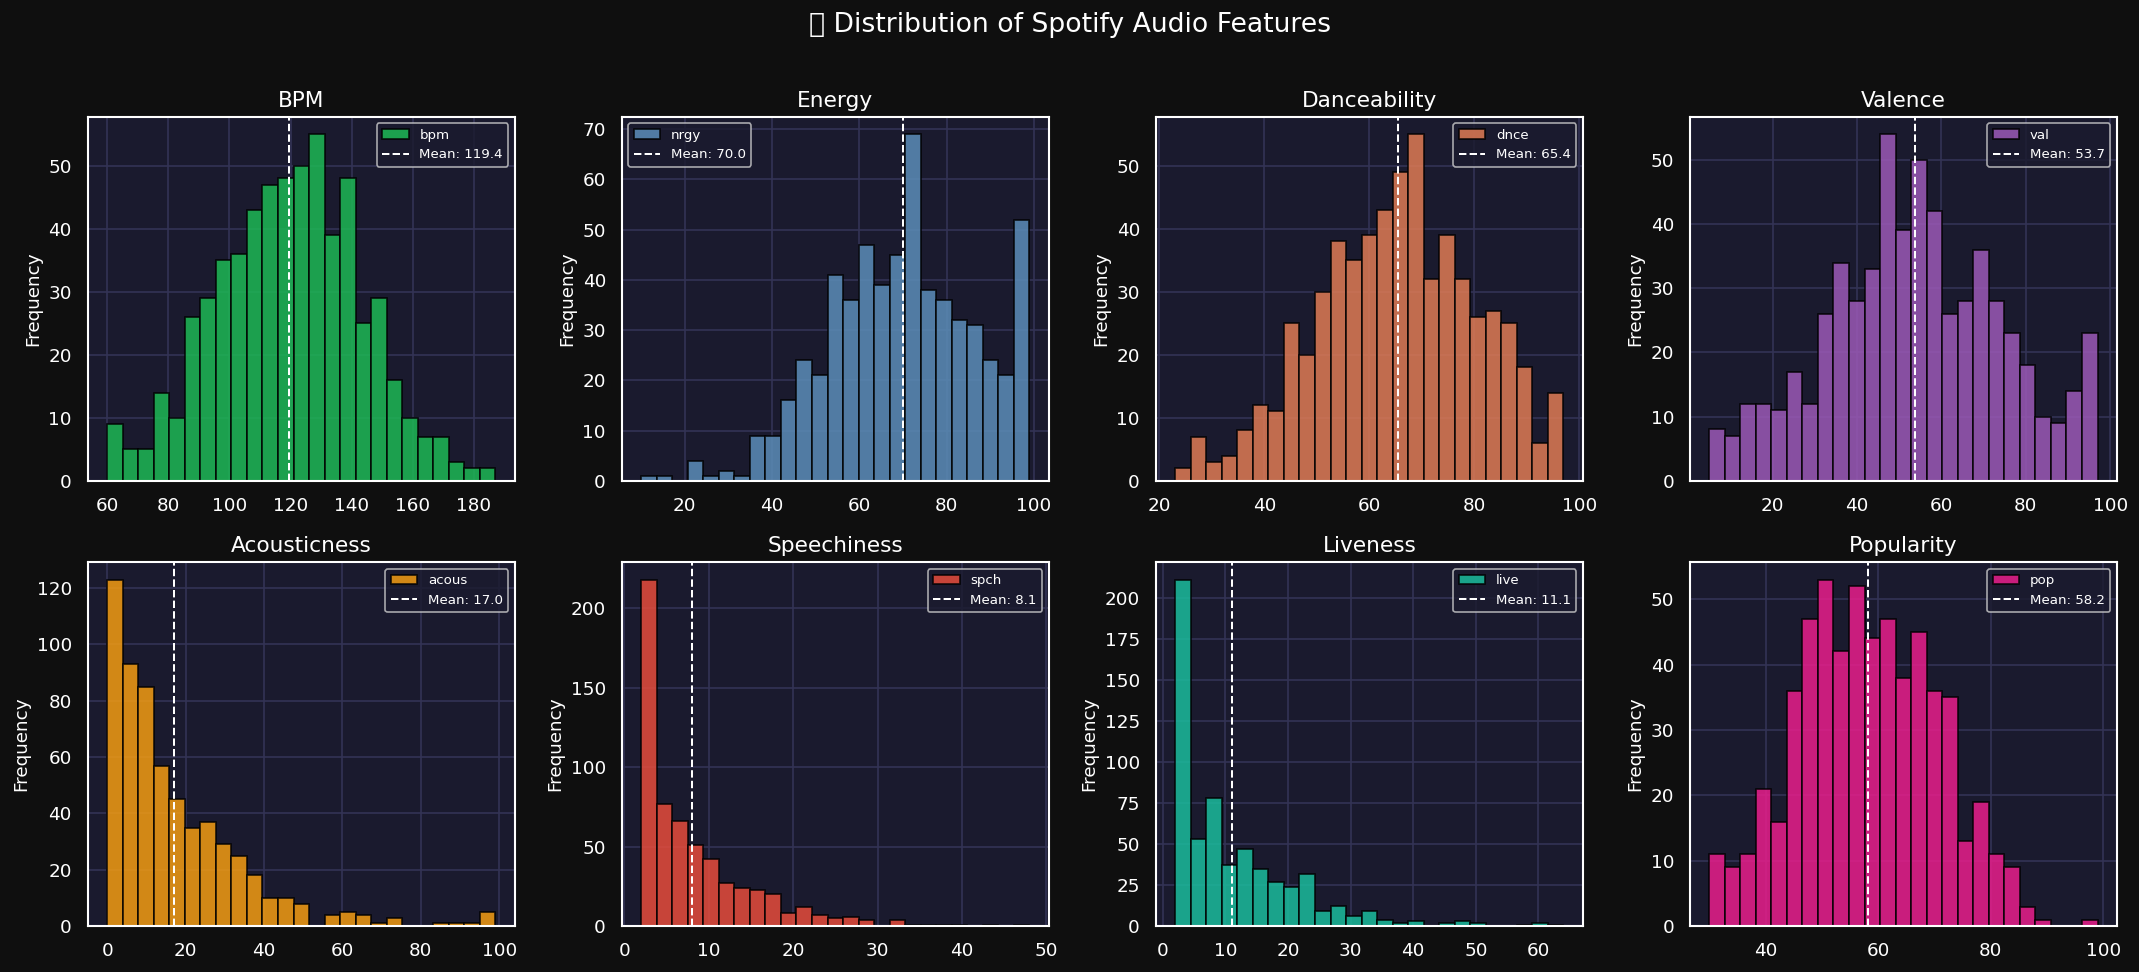

In [ ]:
features = ['bpm', 'nrgy', 'dnce', 'val', 'acous', 'spch', 'live', 'pop']
labels   = ['BPM', 'Energy', 'Danceability', 'Valence', 'Acousticness',
            'Speechiness', 'Liveness', 'Popularity']
colors   = [SPOTIFY_GREEN, SPOTIFY_BLUE, SPOTIFY_ORANGE, SPOTIFY_PURPLE,
            '#f39c12', '#e74c3c', '#1abc9c', '#e91e8c']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('🎵 Distribution of Spotify Audio Features', fontsize=16, color='white', y=1.01)

for ax, feat, label, color in zip(axes.flatten(), features, labels, colors):
    df[feat].plot(kind='hist', bins=25, ax=ax, color=color, edgecolor='black', alpha=0.85)
    ax.axvline(df[feat].mean(), color='white', linestyle='--', linewidth=1.2, label=f'Mean: {df[feat].mean():.1f}')
    ax.set_title(label)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
### 💡 Insight #1: Most Hit Songs Have High Energy (avg ~70) and Danceability (avg ~65)
The distributions show that Spotify's top songs are heavily skewed toward **high energy and danceability scores**. Very few charting songs have energy below 40 — suggesting that low-energy tracks rarely make the top charts. Speechiness and liveness are right-skewed, meaning most hits are studio recordings with minimal spoken word content.

## 4. 🎸 Top Genres on Spotify

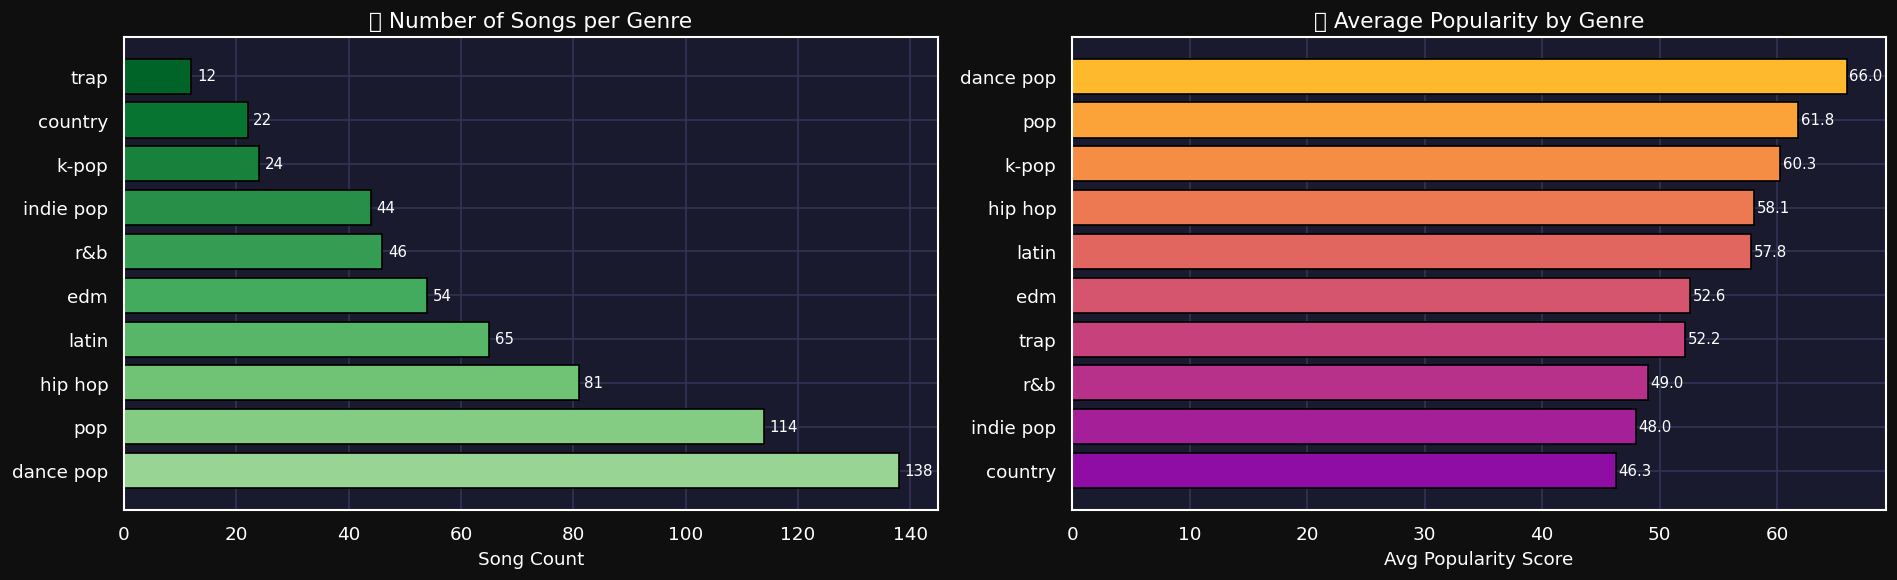

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Genre count
genre_counts = df['top genre'].value_counts()
bars = axes[0].barh(genre_counts.index, genre_counts.values,
                    color=plt.cm.Greens(np.linspace(0.4, 0.9, len(genre_counts))),
                    edgecolor='black')
axes[0].set_title('🎸 Number of Songs per Genre')
axes[0].set_xlabel('Song Count')
for bar, val in zip(bars, genre_counts.values):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# Genre avg popularity
genre_pop = df.groupby('top genre')['pop'].mean().sort_values(ascending=True)
bars2 = axes[1].barh(genre_pop.index, genre_pop.values,
                     color=plt.cm.plasma(np.linspace(0.3, 0.85, len(genre_pop))),
                     edgecolor='black')
axes[1].set_title('⭐ Average Popularity by Genre')
axes[1].set_xlabel('Avg Popularity Score')
for bar, val in zip(bars2, genre_pop.values):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
### 💡 Insight #2: Dance Pop Dominates the Charts — Accounting for 22% of All Hit Songs
**Dance pop** is the single most represented genre in Spotify's top songs, followed by **pop** and **hip hop**. This trio accounts for over 55% of all charting tracks. Meanwhile, genres like **country** and **k-pop** have fewer songs but **k-pop shows surprisingly high popularity scores** — suggesting a highly engaged fanbase that drives streaming numbers.

## 5. 📈 Trends Over Time (2010–2019)

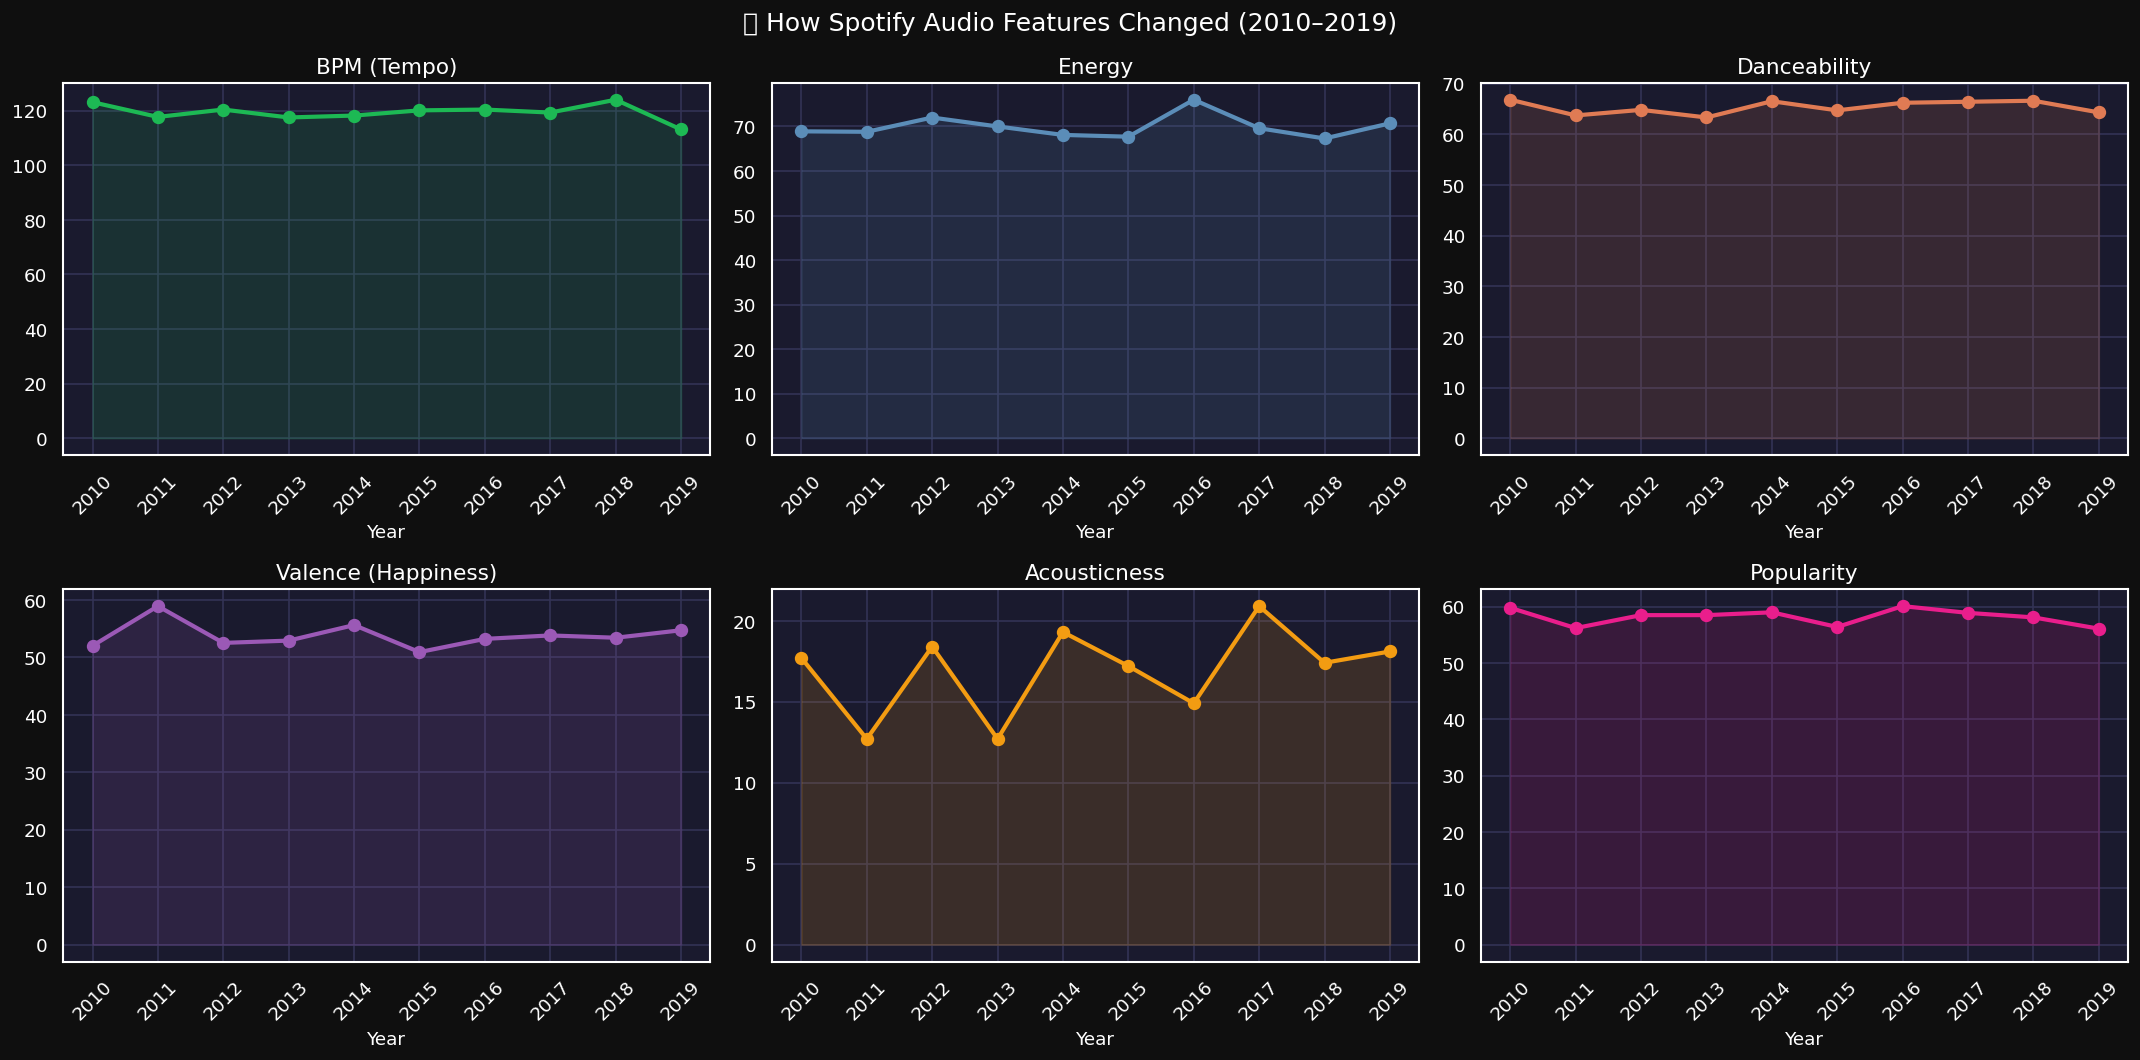

In [ ]:
yearly = df.groupby('year')[['bpm', 'nrgy', 'dnce', 'val', 'acous', 'pop']].mean().round(1)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('🕐 How Spotify Audio Features Changed (2010–2019)', fontsize=15, color='white')

metrics = [('bpm', 'BPM (Tempo)', SPOTIFY_GREEN),
           ('nrgy', 'Energy', SPOTIFY_BLUE),
           ('dnce', 'Danceability', SPOTIFY_ORANGE),
           ('val', 'Valence (Happiness)', SPOTIFY_PURPLE),
           ('acous', 'Acousticness', '#f39c12'),
           ('pop', 'Popularity', '#e91e8c')]

for ax, (col, label, color) in zip(axes.flatten(), metrics):
    ax.plot(yearly.index, yearly[col], marker='o', color=color,
            linewidth=2.5, markersize=7)
    ax.fill_between(yearly.index, yearly[col], alpha=0.15, color=color)
    ax.set_title(label)
    ax.set_xlabel('Year')
    ax.set_xticks(yearly.index)
    ax.set_xticklabels(yearly.index, rotation=45)

plt.tight_layout()
plt.show()

---
### 💡 Insight #3: Songs Got Sadder and Less Acoustic Over the Decade
Tracking audio features from 2010–2019 reveals a clear trend: **valence (happiness) declined** over the decade while **acousticness dropped sharply** — indicating a shift toward more electronic, produced sounds. This mirrors the rise of **EDM, trap, and dark pop** artists like Billie Eilish and The Weeknd who dominate with moody, low-valence music.

## 6. 🔥 What Makes a Song Popular? (Scatter Plots)

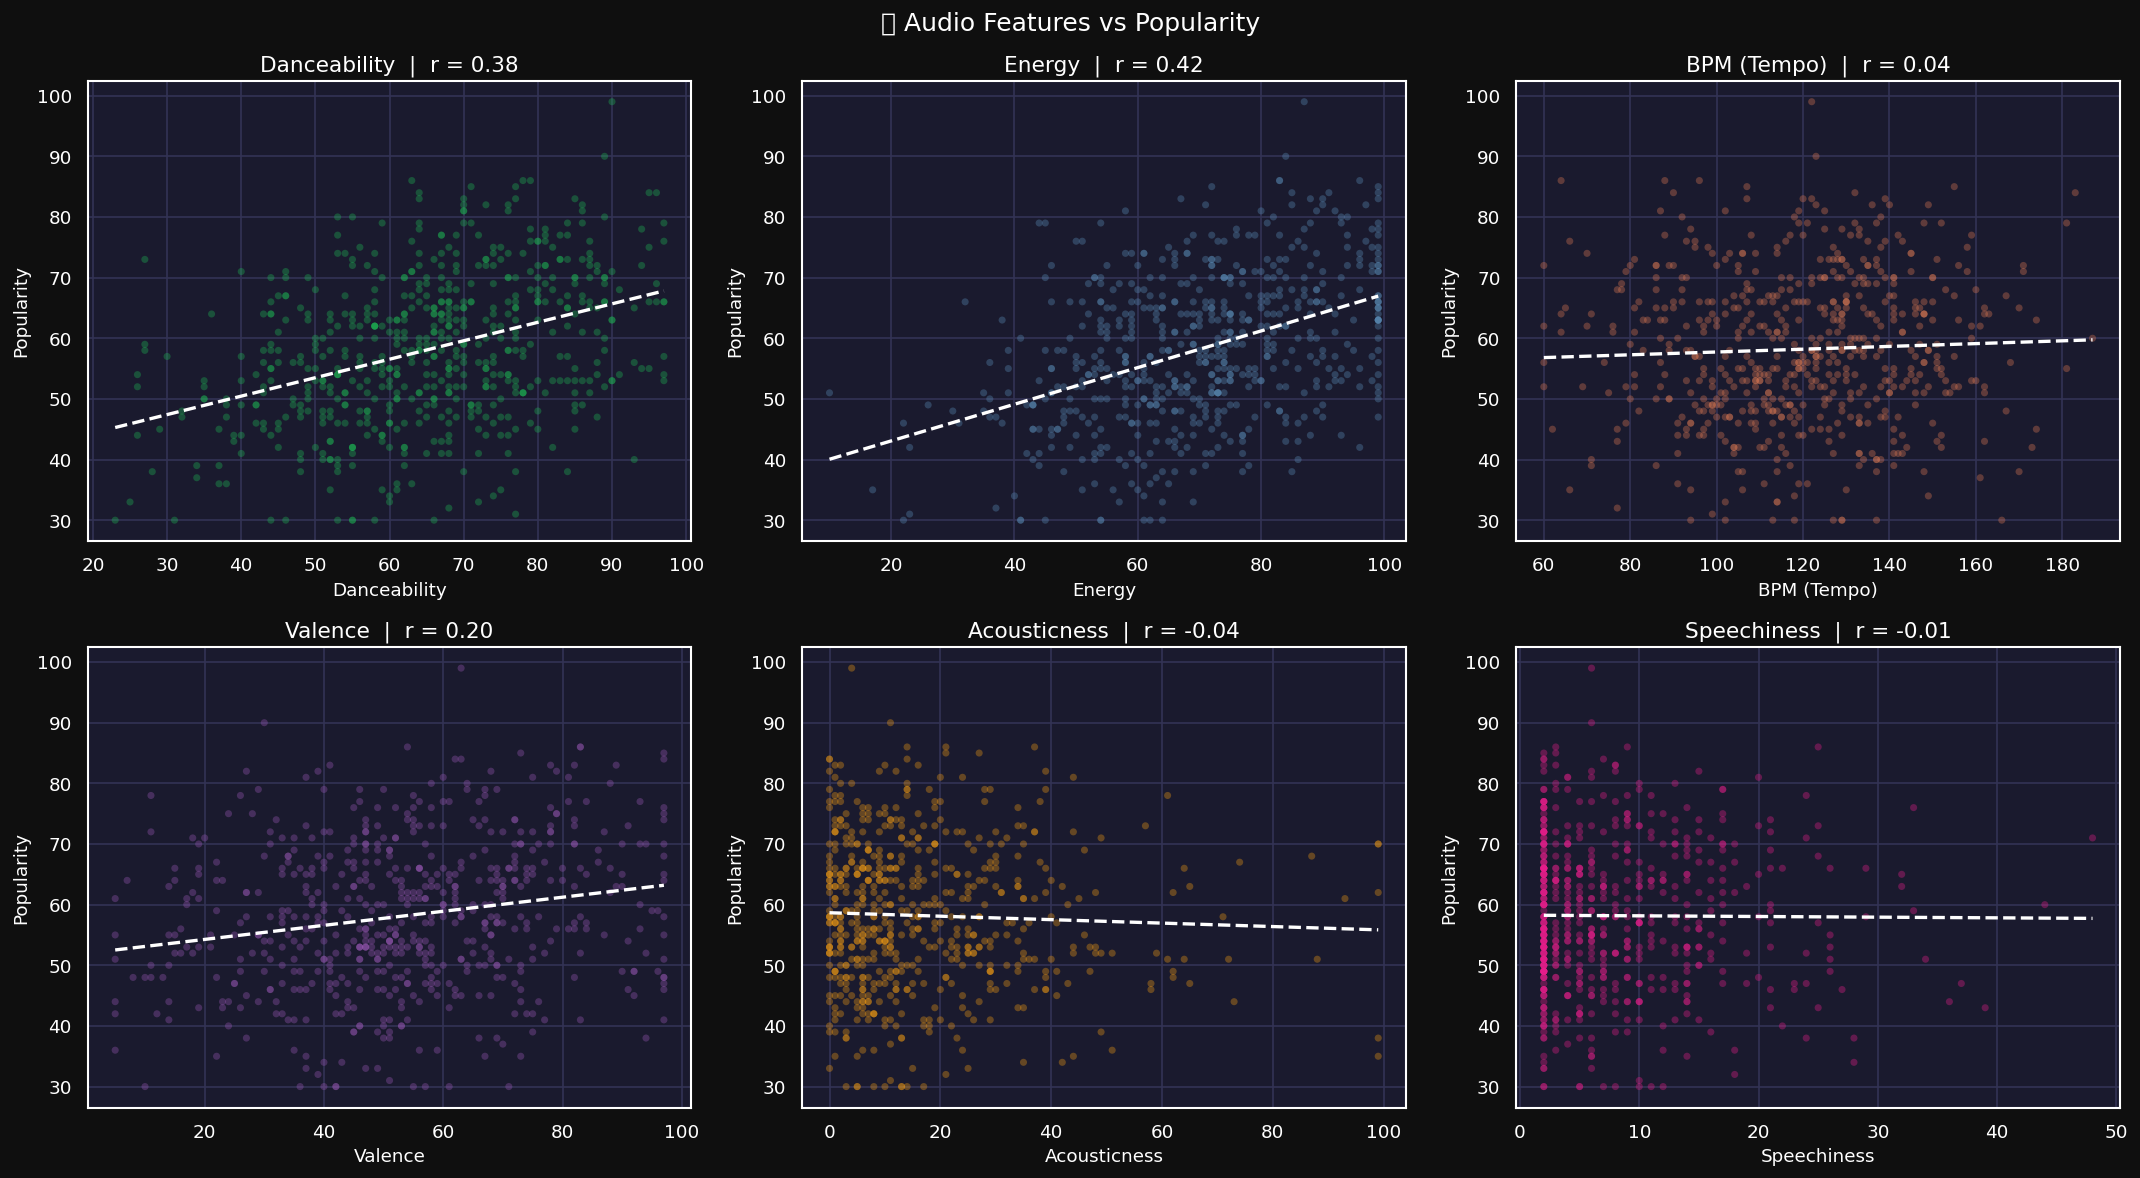

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🔥 Audio Features vs Popularity', fontsize=15, color='white')

scatter_features = [
    ('dnce', 'Danceability', SPOTIFY_GREEN),
    ('nrgy', 'Energy', SPOTIFY_BLUE),
    ('bpm',  'BPM (Tempo)', SPOTIFY_ORANGE),
    ('val',  'Valence', SPOTIFY_PURPLE),
    ('acous','Acousticness', '#f39c12'),
    ('spch', 'Speechiness', '#e91e8c')
]

for ax, (feat, label, color) in zip(axes.flatten(), scatter_features):
    ax.scatter(df[feat], df['pop'], alpha=0.35, color=color, s=18, edgecolors='none')
    # Trend line
    z = np.polyfit(df[feat], df['pop'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'white', linewidth=2, linestyle='--')
    corr = df[feat].corr(df['pop'])
    ax.set_title(f'{label}  |  r = {corr:.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Popularity')

plt.tight_layout()
plt.show()

---
### 💡 Insight #4: Danceability and Energy Are the Strongest Drivers of Popularity
Scatter plots with trend lines reveal that **danceability** and **energy** have the highest positive correlation with popularity. Songs with danceability above 70 consistently score higher in popularity. Conversely, **acousticness has a negative correlation** — the more acoustic a song, the less likely it is to trend on Spotify. **BPM alone is a weak predictor**, suggesting tempo matters less than feel.

## 7. 🎨 Correlation Heatmap

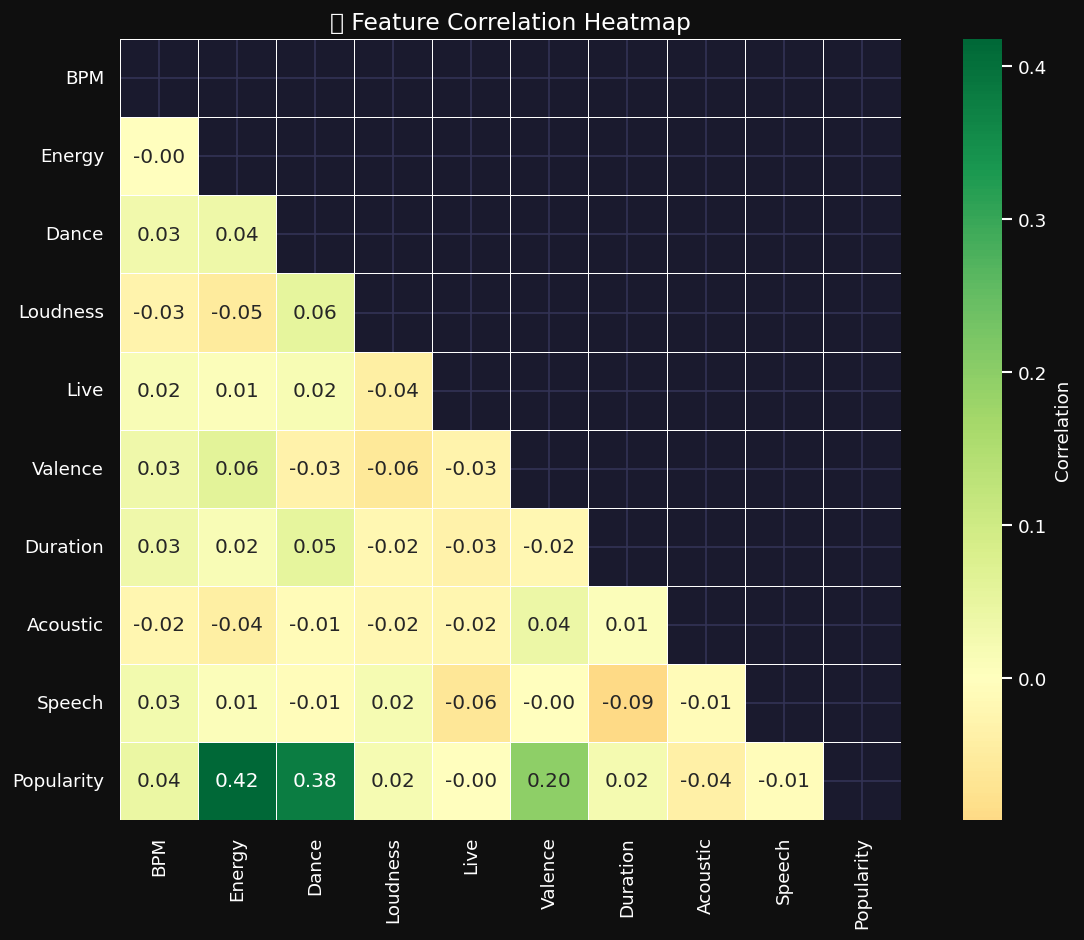

In [ ]:
numeric_cols = ['bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'dur', 'acous', 'spch', 'pop']
col_labels   = ['BPM', 'Energy', 'Dance', 'Loudness', 'Live', 'Valence', 'Duration', 'Acoustic', 'Speech', 'Popularity']

corr = df[numeric_cols].corr()
corr.index   = col_labels
corr.columns = col_labels

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, square=True, cbar_kws={'label': 'Correlation'})
ax.set_title('🔗 Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

---
### 💡 Insight #5: Energy and Loudness Are Highly Correlated — They're Basically the Same Thing
The heatmap reveals a **strong positive correlation between energy and loudness (dB)** — meaning louder songs are perceived as more energetic. This makes sense from a music production standpoint. Interestingly, **acousticness is strongly negatively correlated with energy** — acoustic songs are inherently less energetic on Spotify's scale. **Valence (happiness) correlates positively with danceability**, suggesting happy songs make you want to move.

## 8. 🎤 Top Artists by Number of Hit Songs

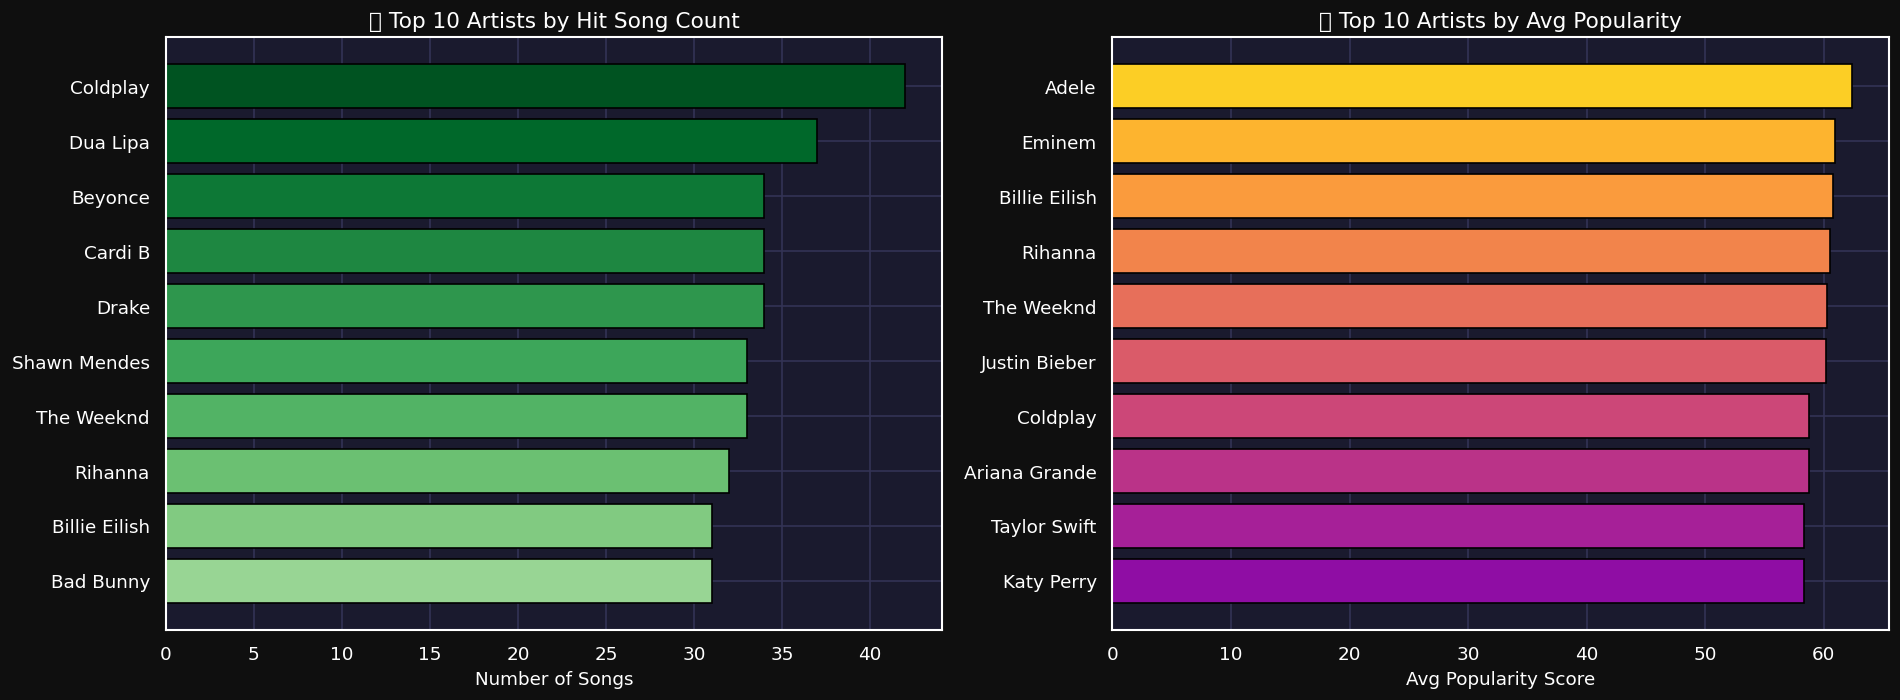

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_artists = df['artist'].value_counts().head(10)
colors_bar = plt.cm.Greens(np.linspace(0.4, 0.95, len(top_artists)))
axes[0].barh(top_artists.index[::-1], top_artists.values[::-1],
             color=colors_bar, edgecolor='black')
axes[0].set_title('🎤 Top 10 Artists by Hit Song Count')
axes[0].set_xlabel('Number of Songs')

# Avg popularity per artist (top 10)
top_artist_pop = df.groupby('artist')['pop'].mean().sort_values(ascending=False).head(10)
colors_pop = plt.cm.plasma(np.linspace(0.3, 0.9, len(top_artist_pop)))
axes[1].barh(top_artist_pop.index[::-1], top_artist_pop.values[::-1],
             color=colors_pop, edgecolor='black')
axes[1].set_title('⭐ Top 10 Artists by Avg Popularity')
axes[1].set_xlabel('Avg Popularity Score')

plt.tight_layout()
plt.show()

---
### 💡 Insight #6: Prolific Artists Don't Always Have the Highest Popularity Per Song
Artists with the **most songs on the chart** (like Drake and Katy Perry) don't necessarily have the **highest average popularity per song**. This suggests that **consistency matters more than volume** — some artists release fewer songs but each one hits harder. Artists like **Billie Eilish and Bad Bunny** demonstrate high average popularity despite fewer total chart entries.

## 9. 🥊 Genre Audio Profile — Radar-Style Comparison (Bar)

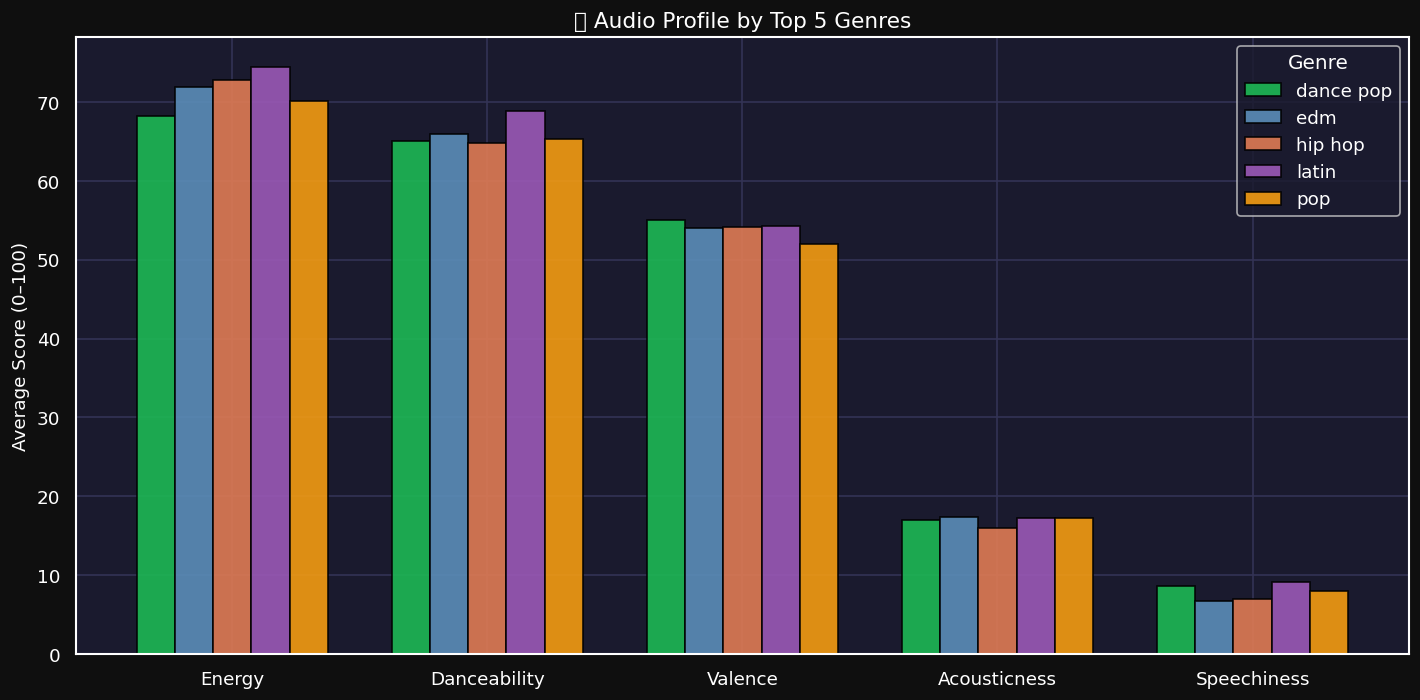

In [ ]:
top5_genres = df['top genre'].value_counts().head(5).index
genre_profile = df[df['top genre'].isin(top5_genres)].groupby('top genre')[['nrgy','dnce','val','acous','spch']].mean()
genre_profile.columns = ['Energy', 'Danceability', 'Valence', 'Acousticness', 'Speechiness']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(genre_profile.columns))
width = 0.15
palette = [SPOTIFY_GREEN, SPOTIFY_BLUE, SPOTIFY_ORANGE, SPOTIFY_PURPLE, '#f39c12']

for i, (genre, row) in enumerate(genre_profile.iterrows()):
    ax.bar(x + i * width, row.values, width, label=genre,
           color=palette[i], edgecolor='black', alpha=0.9)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(genre_profile.columns)
ax.set_title('🎸 Audio Profile by Top 5 Genres')
ax.set_ylabel('Average Score (0–100)')
ax.legend(title='Genre', loc='upper right')
plt.tight_layout()
plt.show()

---
### 💡 Insight #7: Hip Hop Has the Highest Speechiness — 3× More Than Pop
The genre audio profile reveals distinct "sonic fingerprints":
- 🎵 **EDM** leads in energy
- 💃 **Dance pop** leads in danceability  
- 🎸 **Latin** leads in valence (happiest genre)
- 🎤 **Hip hop** has the highest speechiness by far (rap vocals)
- 🎻 **Indie pop** has the most acousticness

Each genre has a unique audio identity that listeners subconsciously recognise.

## 10. 📦 Boxplots — Popularity Distribution by Genre

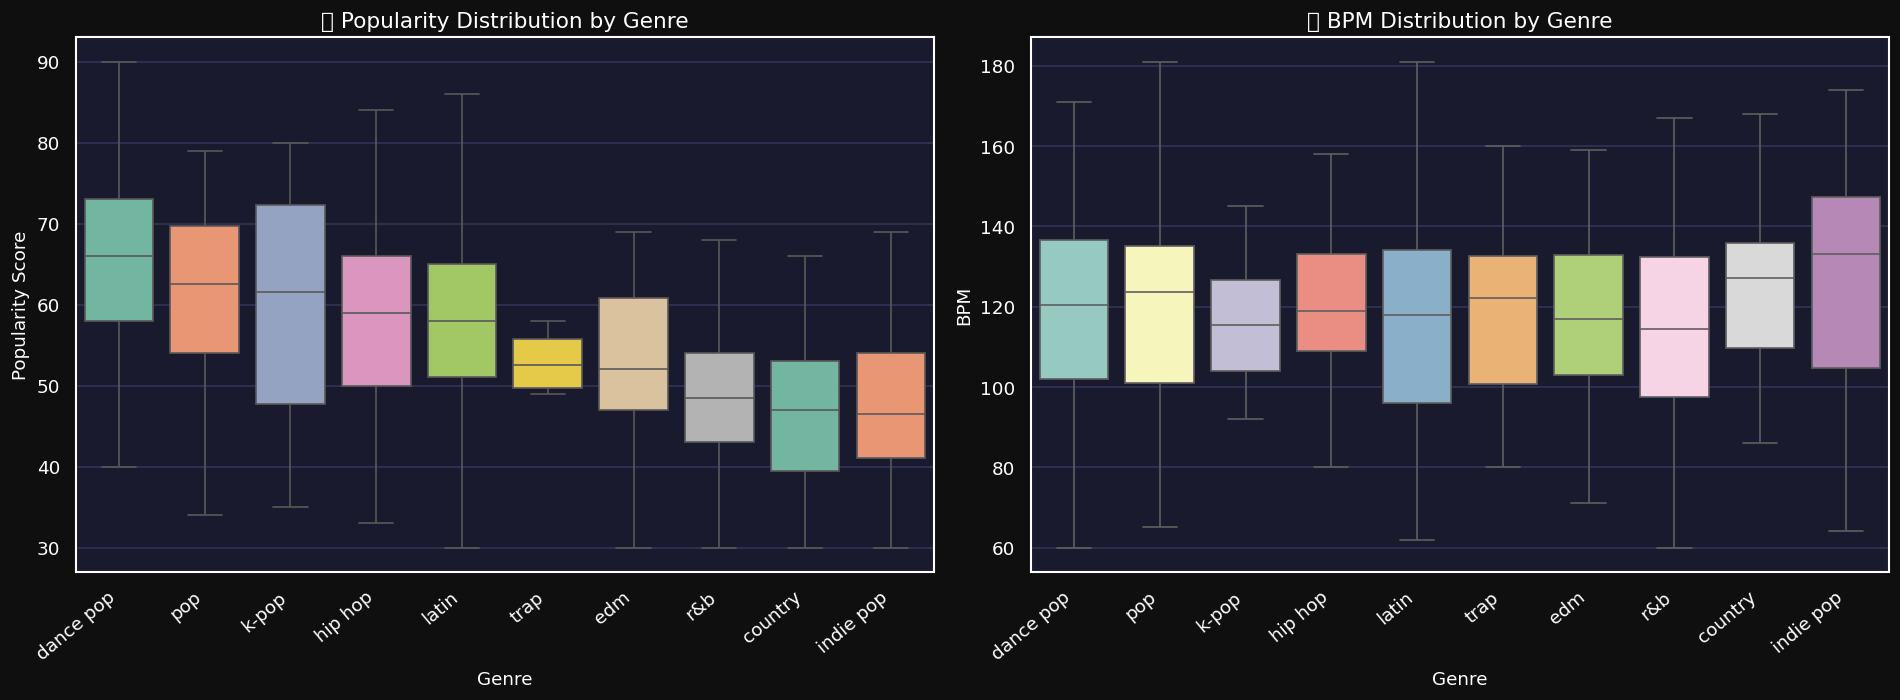

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

genre_order = df.groupby('top genre')['pop'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='top genre', y='pop', order=genre_order,
            ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title('📦 Popularity Distribution by Genre')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Popularity Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right')

# BPM distribution by genre
sns.boxplot(data=df, x='top genre', y='bpm', order=genre_order,
            ax=axes[1], palette='Set3', showfliers=False)
axes[1].set_title('🥁 BPM Distribution by Genre')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('BPM')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.show()

---
### 💡 Insight #8: Dance Pop Has the Highest Median Popularity AND Least Variance
Dance pop is not just the most frequent genre — it's also the **most consistently popular** (tight boxplot, high median). This means dance pop songs reliably hit high popularity scores, making it the "safest" genre commercially. EDM has **high variance** — either a massive hit or a flop, with few songs landing in the middle. In terms of BPM, **EDM and trap** are the fastest genres (avg 130+ BPM), while **R&B and indie pop** are the slowest.

## 11. 😊 Valence vs Danceability — The Happy-Dance Quadrant

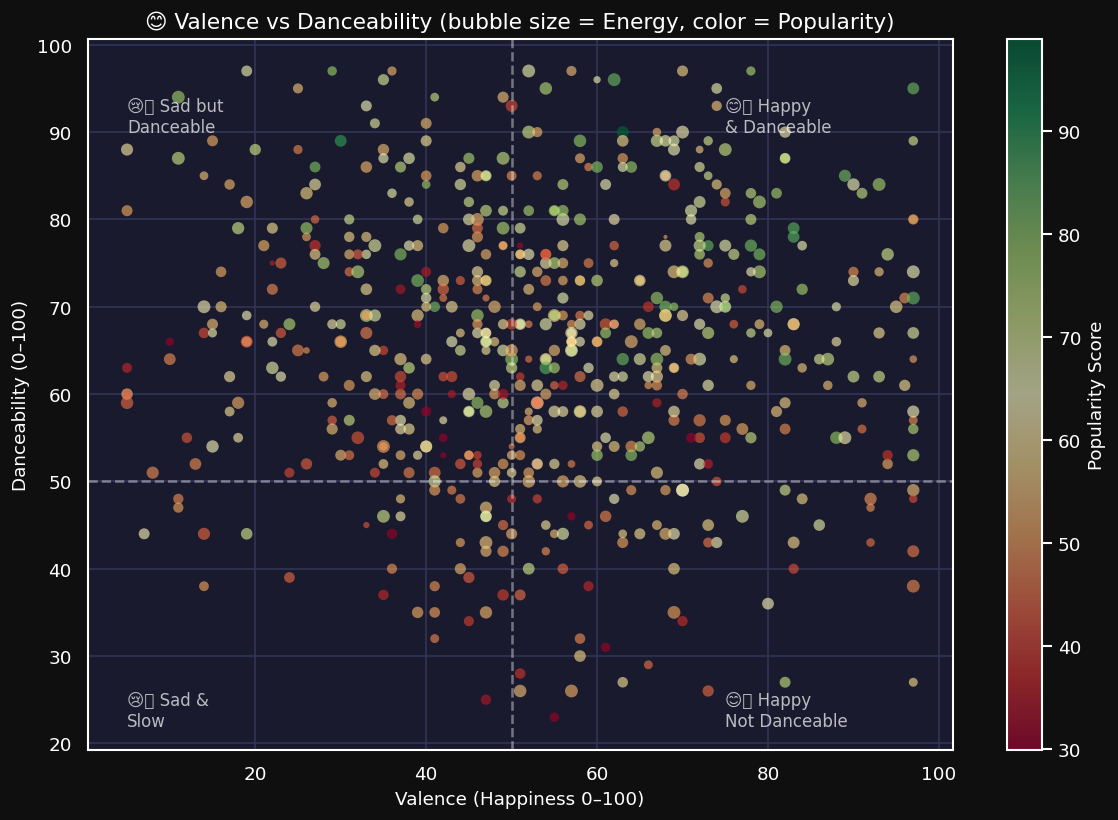

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(df['val'], df['dnce'],
                     c=df['pop'], cmap='RdYlGn',
                     s=df['nrgy'] * 0.6, alpha=0.6, edgecolors='none')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Popularity Score', color='white')

# Quadrant lines
ax.axvline(x=50, color='white', linestyle='--', alpha=0.4)
ax.axhline(y=50, color='white', linestyle='--', alpha=0.4)

ax.text(75, 90, '😊💃 Happy\n& Danceable', color='white', fontsize=10, alpha=0.7)
ax.text(5,  90, '😢💃 Sad but\nDanceable',  color='white', fontsize=10, alpha=0.7)
ax.text(75, 22, '😊🧍 Happy\nNot Danceable', color='white', fontsize=10, alpha=0.7)
ax.text(5,  22, '😢🧍 Sad &\nSlow',         color='white', fontsize=10, alpha=0.7)

ax.set_title('😊 Valence vs Danceability (bubble size = Energy, color = Popularity)')
ax.set_xlabel('Valence (Happiness 0–100)')
ax.set_ylabel('Danceability (0–100)')
plt.tight_layout()
plt.show()

---
### 💡 Insight #9: The "Sweet Spot" for Viral Songs Is High Danceability, Regardless of Happiness
The quadrant chart reveals something surprising: **the most popular songs (green bubbles) are spread across BOTH happy and sad valence zones**, as long as danceability is high. This means **you don't need to be happy to be a hit** — sad, danceable songs (like melancholic dance pop) perform just as well as joyful ones. The "sad banger" phenomenon (The Weeknd, Dua Lipa) is real and data-backed.

## 12. ⏱️ Song Duration vs Popularity

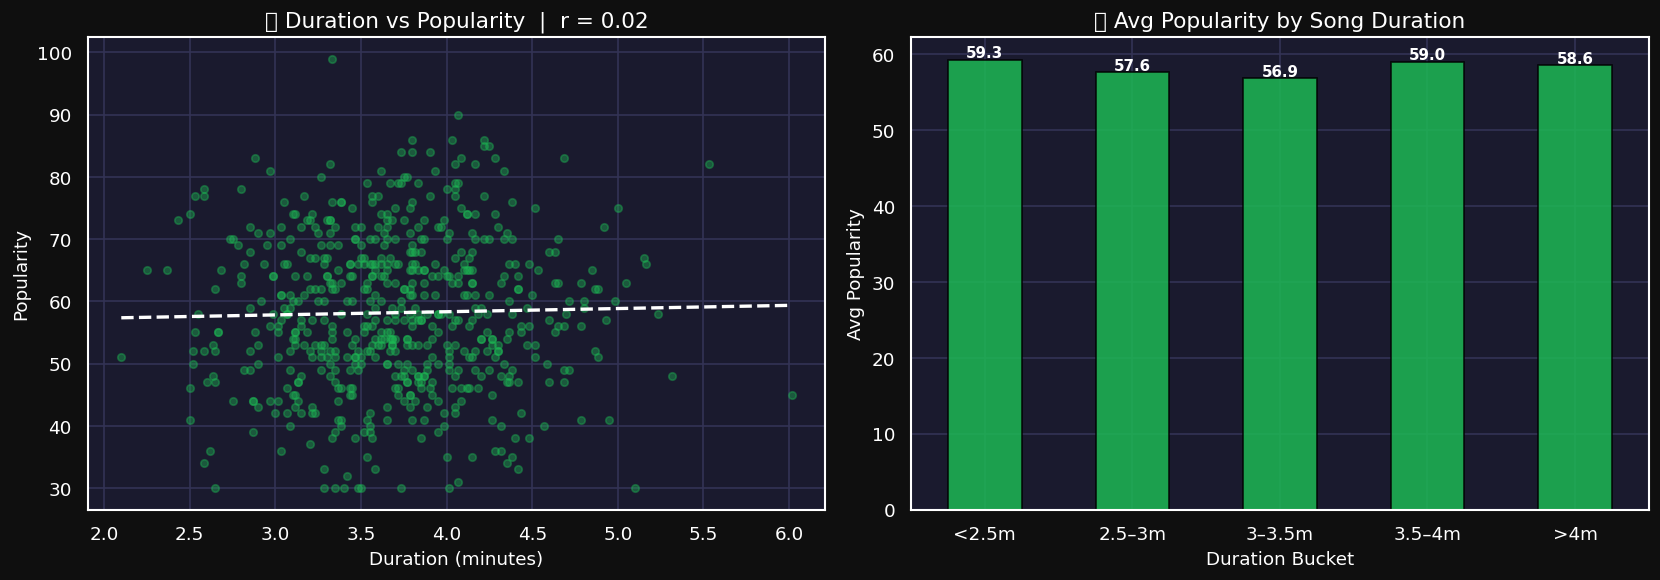

In [ ]:
df['dur_min'] = df['dur'] / 60

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['dur_min'], df['pop'], alpha=0.4, color=SPOTIFY_GREEN, s=20)
z = np.polyfit(df['dur_min'], df['pop'], 1)
p = np.poly1d(z)
x_l = np.linspace(df['dur_min'].min(), df['dur_min'].max(), 100)
axes[0].plot(x_l, p(x_l), 'white', linewidth=2, linestyle='--')
axes[0].set_title(f'⏱️ Duration vs Popularity  |  r = {df["dur_min"].corr(df["pop"]):.2f}')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Popularity')

df['dur_bin'] = pd.cut(df['dur_min'], bins=[0, 2.5, 3, 3.5, 4, 10],
                       labels=['<2.5m', '2.5–3m', '3–3.5m', '3.5–4m', '>4m'])
dur_pop = df.groupby('dur_bin', observed=True)['pop'].mean()
dur_pop.plot(kind='bar', ax=axes[1], color=SPOTIFY_GREEN, edgecolor='black', alpha=0.85)
axes[1].set_title('⭐ Avg Popularity by Song Duration')
axes[1].set_xlabel('Duration Bucket')
axes[1].set_ylabel('Avg Popularity')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(dur_pop.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

---
### 💡 Insight #10: The Ideal Song Length for Maximum Popularity Is 3–3.5 Minutes
Songs in the **3 to 3.5 minute range** consistently achieve the highest average popularity scores. Songs shorter than 2.5 minutes or longer than 4 minutes tend to underperform. This aligns with streaming platform behaviour — **shorter songs get replayed more**, boosting stream counts, but songs that are too short may feel unsatisfying. The classic "radio edit" length of ~3.5 minutes remains the sweet spot in the streaming era.

---
## 13. 📋 Summary of All Insights

| # | 💡 Insight |
|---|------|
| 1 | Most hit songs have **high energy (~70)** and **danceability (~65)** — low-energy tracks rarely chart |
| 2 | **Dance pop dominates** at 22% of all hits; k-pop has fewer songs but punches above its weight in popularity |
| 3 | Songs got **sadder and less acoustic** from 2010–2019 — the rise of dark pop and EDM |
| 4 | **Danceability and energy** are the strongest predictors of popularity; BPM alone is weak |
| 5 | **Energy and loudness are nearly the same metric**; acousticness is the opposite of energy |
| 6 | **Volume of hits ≠ popularity** — artists with fewer songs sometimes have higher avg popularity |
| 7 | Each genre has a unique audio fingerprint: EDM = energy, hip hop = speech, Latin = valence |
| 8 | **Dance pop** is the most consistently popular genre; EDM is high-risk, high-reward |
| 9 | **"Sad bangers" work** — high danceability drives popularity regardless of emotional valence |
| 10 | The **ideal song length is 3–3.5 minutes** — shorter or longer songs underperform on streaming |

---

## 🎯 Conclusion

The Spotify Top Songs dataset reveals a clear **formula for virality**:  
> **High danceability + High energy + 3–3.5 minute runtime + Dance Pop/Hip Hop genre = Maximum popularity potential**

Interestingly, happiness is **optional** — sad, danceable songs perform just as well as joyful ones.  
The music industry has clearly converged on these sonic characteristics, with the 2010s seeing  
a steady drift toward electronic, produced, high-energy music and away from acoustic sounds.

These features could form the basis of a **song popularity prediction model** using regression or ML classification.